# # 대학생 중도탈락 예측 모델링 (XGBoost)
- **목표**: XGBoost와 하이퍼파라미터 튜닝을 통한 고성능 이탈 예측 분류기 구축
- **담당**: XGBoost 모델링 및 성능 평가

# Baseline Modeling (XGBoost)

튜닝의 주 기준: **F1-score**

반드시 별도로 확인: **Dropout Recall**

추가적인 모델 변별력 확인: **ROC-AUC**

하이퍼파라미터 튜닝
   - RandomizedSearchCV 사용
   - 탐색 방법: Randomized Search
   - CV 방법: Stratified K-Fold
   - K = 5
   - Train 데이터 안에서만 CV를 수행
   - Validation과 Test 데이터는 CV에 사용하지 않는다.
   - RandomizedSearchCV의 scoring은 F1-score를 사용한다.
   - 즉, 여러 하이퍼파라미터 조합 중 CV 평균 F1이 가장 높은 조합을 최적 파라미터로 선택한다.

In [20]:
import matplotlib.pyplot as plt

# 윈도우 기본 한글 폰트(맑은 고딕) 설정 및 마이너스 기호 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# Baseline XGBoost

#### X(학생 정보) → Dropout 여부(Y)

# 핵심 가설
- 학생의 학업 성취도, 재정 상태, 등록 관련 정보 및 개인적 특성은 중도탈락 여부와 관련이 있으며, 이를 종합적으로 활용하면 중도탈락 학생을 사전에 식별할 수 있다.

### 학생의 학업·재정·인구통계학적 특성을 활용하여 중도탈락 가능성을 예측하고, 모델의 성능을 평가함으로써 중도탈락 학생을 사전에 식별할 수 있는 가능성을 확인한다.  
### XGBoost의 Feature Importance를 통해 어떤 학생 특성이 중도탈락 예측에 상대적으로 중요한 정보를 제공하는지 분석한다.

① 중도탈락을 예측할 수 있는가?  
② 실제 중도탈락 학생을 얼마나 잘 찾아낼 수 있는가?  
③ 어떤 변수들이 예측에 중요한 정보를 제공하는가?

scale_pos_weight = 2.1150

Baseline XGBoost 학습 시작...
Baseline 학습 완료!

[Baseline XGBoost - Feature Importance TOP 10]
                                 Feature  Importance
                 num__sem2_approval_rate    0.164985
       cat__Father_education_level_미상·기타    0.063660
         remainder__financial_risk_score    0.048276
      remainder__Tuition fees up to date    0.045401
                 cat__Major_field_예술·디자인    0.028179
num__Curricular units 1st sem (enrolled)    0.023097
                     cat__Major_field_사회    0.021388
          cat__Father_education_level_대학    0.021288
                  cat__Major_field_인문·사회    0.020770
    remainder__Educational special needs    0.020672

[Baseline XGBoost - Validation 성능]
Accuracy       : 0.8531
Precision      : 0.7508
Dropout Recall : 0.8140
F1-score       : 0.7811
ROC-AUC        : 0.9162

[Classification Report]
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.87      0.89       600
     Dropo

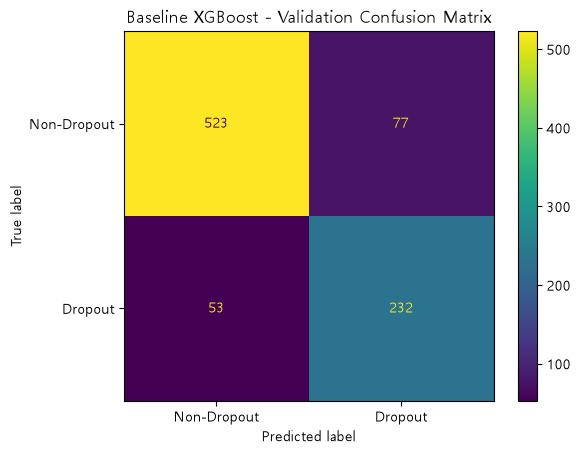


[Baseline XGBoost - Test 최종 성능]
Accuracy       : 0.8768
Precision      : 0.8159
Dropout Recall : 0.7958
F1-score       : 0.8057
ROC-AUC        : 0.9149

[Classification Report]
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.92      0.91       601
     Dropout       0.82      0.80      0.81       284

    accuracy                           0.88       885
   macro avg       0.86      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885


[Test Confusion Matrix]
[[550  51]
 [ 58 226]]

구성:
TN (실제 0 → 예측 0) : 550
FP (실제 0 → 예측 1) : 51
FN (실제 1 → 예측 0) : 58
TP (실제 1 → 예측 1) : 226


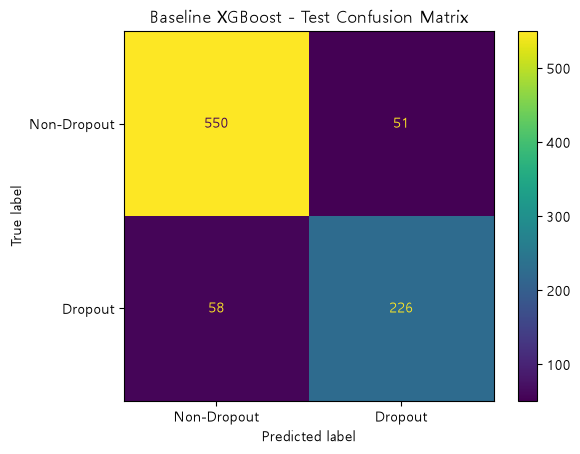


[Baseline 최종 결과 요약]
           Model  Accuracy  Precision  Dropout Recall  F1-score  ROC-AUC
Baseline XGBoost  0.876836   0.815884        0.795775  0.805704 0.914942


In [21]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# =====================================================================
# [1단계] 데이터 불러오기
# =====================================================================
# 전처리가 끝난 Train / Validation / Test 데이터를 불러옵니다.
#
# Train      → 모델 학습
# Validation → 모델의 중간 성능 확인
# Test       → 최종 성능 평가
# =====================================================================

train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')


# =====================================================================
# [2단계] X와 y 분리
# =====================================================================

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_val = val_df.drop('target', axis=1)
y_val = val_df['target']

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']


# =====================================================================
# [3단계] 클래스 불균형 가중치 계산
# =====================================================================
# 0 클래스와 1 클래스의 데이터 개수를 확인합니다.
#
# 현재 프로젝트에서는
# 0 = Non-Dropout
# 1 = Dropout
#
# scale_pos_weight는 상대적으로 적은 클래스인 1(Dropout)을
# 모델이 더 중요하게 학습하도록 만들어줍니다.
#
# 공식:
#
#       0의 개수
# -------------------
#       1의 개수
# =====================================================================

weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(f"scale_pos_weight = {weight:.4f}")


# =====================================================================
# [4단계] Baseline XGBoost 생성
# =====================================================================

baseline_model = XGBClassifier(
    scale_pos_weight=weight,
    random_state=42
)


# =====================================================================
# [5단계] Baseline 모델 학습
# =====================================================================

print("\nBaseline XGBoost 학습 시작...")

baseline_model.fit(X_train, y_train)

print("Baseline 학습 완료!")



# =====================================================================
# [Feature Importance]
# XGBoost가 예측할 때 각 Feature(컬럼)를 얼마나 중요하게 활용했는지 확인
# =====================================================================

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': baseline_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("\n" + "=" * 60)
print("[Baseline XGBoost - Feature Importance TOP 10]")
print("=" * 60)

print(importance_df.head(10).to_string(index=False))


# =====================================================================
# [6단계] Validation 데이터 예측
# =====================================================================
# predict_proba()는 각 클래스에 대한 "확률"을 반환합니다.
#
# [:, 1]
# → Dropout(1)일 확률만 가져옵니다.
#
# 예:
# 0.82 → Dropout일 확률 82%
# 0.31 → Dropout일 확률 31%
#
# Threshold 0.5를 기준으로 최종 클래스를 결정합니다.
# =====================================================================

val_proba = baseline_model.predict_proba(X_val)[:, 1]

val_pred = (val_proba >= 0.5).astype(int)


# =====================================================================
# [7단계] Validation 성능 계산
# =====================================================================

val_accuracy = accuracy_score(y_val, val_pred)

val_precision = precision_score(
    y_val,
    val_pred,
    pos_label=1
)

val_recall = recall_score(
    y_val,
    val_pred,
    pos_label=1
)

val_f1 = f1_score(
    y_val,
    val_pred,
    pos_label=1
)

val_roc_auc = roc_auc_score(
    y_val,
    val_proba
)


# =====================================================================
# [8단계] Validation 결과 출력
# =====================================================================

print("\n" + "=" * 60)
print("[Baseline XGBoost - Validation 성능]")
print("=" * 60)

print(f"Accuracy       : {val_accuracy:.4f}")
print(f"Precision      : {val_precision:.4f}")
print(f"Dropout Recall : {val_recall:.4f}")
print(f"F1-score       : {val_f1:.4f}")
print(f"ROC-AUC        : {val_roc_auc:.4f}")


# Classification Report
# → 클래스별 Precision / Recall / F1을 한 번에 확인
print("\n[Classification Report]")

print(
    classification_report(
        y_val,
        val_pred,
        target_names=['Non-Dropout', 'Dropout']
    )
)


# =====================================================================
# [9단계] Validation Confusion Matrix
# =====================================================================
# Confusion Matrix의 구조:
#
#                  예측
#             0          1
#
# 실제 0      TN         FP
# 실제 1      FN         TP
#
# FN:
# 실제 Dropout인데 Non-Dropout이라고 예측
#
# TP:
# 실제 Dropout이고 Dropout이라고 정확히 예측
#
# 우리 프로젝트에서는 FN을 특히 중요하게 봅니다.
# =====================================================================

val_cm = confusion_matrix(y_val, val_pred)

print("\n[Validation Confusion Matrix]")
print(val_cm)

print("\n구성:")
print(f"TN (실제 0 → 예측 0) : {val_cm[0, 0]}")
print(f"FP (실제 0 → 예측 1) : {val_cm[0, 1]}")
print(f"FN (실제 1 → 예측 0) : {val_cm[1, 0]}")
print(f"TP (실제 1 → 예측 1) : {val_cm[1, 1]}")


# Confusion Matrix 시각화
ConfusionMatrixDisplay(
    confusion_matrix=val_cm,
    display_labels=['Non-Dropout', 'Dropout']
).plot()

plt.title('Baseline XGBoost - Validation Confusion Matrix')
plt.show()


# =====================================================================
# [10단계] Test 데이터 예측
# =====================================================================
# Test는 최종 평가용입니다.
#
# 여기서는 Threshold를 다시 조정하지 않습니다.
# Validation과 동일하게 0.5를 사용합니다.
# =====================================================================

test_proba = baseline_model.predict_proba(X_test)[:, 1]

test_pred = (test_proba >= 0.5).astype(int)


# =====================================================================
# [11단계] Test 성능 계산
# =====================================================================

test_accuracy = accuracy_score(y_test, test_pred)

test_precision = precision_score(
    y_test,
    test_pred,
    pos_label=1
)

test_recall = recall_score(
    y_test,
    test_pred,
    pos_label=1
)

test_f1 = f1_score(
    y_test,
    test_pred,
    pos_label=1
)

test_roc_auc = roc_auc_score(
    y_test,
    test_proba
)


# =====================================================================
# [12단계] Baseline 최종 Test 결과
# =====================================================================

print("\n" + "=" * 60)
print("[Baseline XGBoost - Test 최종 성능]")
print("=" * 60)

print(f"Accuracy       : {test_accuracy:.4f}")
print(f"Precision      : {test_precision:.4f}")
print(f"Dropout Recall : {test_recall:.4f}")
print(f"F1-score       : {test_f1:.4f}")
print(f"ROC-AUC        : {test_roc_auc:.4f}")


print("\n[Classification Report]")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=['Non-Dropout', 'Dropout']
    )
)


# =====================================================================
# [13단계] Test Confusion Matrix
# =====================================================================

test_cm = confusion_matrix(y_test, test_pred)

print("\n[Test Confusion Matrix]")
print(test_cm)

print("\n구성:")
print(f"TN (실제 0 → 예측 0) : {test_cm[0, 0]}")
print(f"FP (실제 0 → 예측 1) : {test_cm[0, 1]}")
print(f"FN (실제 1 → 예측 0) : {test_cm[1, 0]}")
print(f"TP (실제 1 → 예측 1) : {test_cm[1, 1]}")


ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=['Non-Dropout', 'Dropout']
).plot()

plt.title('Baseline XGBoost - Test Confusion Matrix')
plt.show()


# =====================================================================
# [14단계] Baseline 최종 결과를 DataFrame으로 저장
# =====================================================================
# 나중에 Tuned XGBoost와 비교하기 위한 표입니다.
# =====================================================================

baseline_result = pd.DataFrame({
    'Model': ['Baseline XGBoost'],
    'Accuracy': [test_accuracy],
    'Precision': [test_precision],
    'Dropout Recall': [test_recall],
    'F1-score': [test_f1],
    'ROC-AUC': [test_roc_auc]
})

print("\n" + "=" * 60)
print("[Baseline 최종 결과 요약]")
print("=" * 60)

print(baseline_result.to_string(index=False))

**BaseLine**  
F1          0.8057  
Recall      0.7958  
ROC-AUC     0.9149  

=> "학생 정보를 이용한 중도탈락 예측이 가능하다는 가설을 지지한다."

===========================================================================================================================================================
가설: 학생의 특성 및 학업·재정 정보를 활용하면 중도탈락 여부를 예측할 수 있을 것이다.

결과: Baseline XGBoost에서 Test F1=0.806, Dropout Recall=0.796, ROC-AUC=0.915를 기록했다.

해석: 학생 정보와 중도탈락 여부 사이에 모델이 학습할 수 있는 뚜렷한 패턴이 존재하며, 해당 정보를 이용해 중도탈락 학생을 상당한 수준으로 식별할 수 있음을 확인했다.

추가 분석: Feature Importance를 통해 모델이 어떤 변수들을 중도탈락 예측에 중요하게 활용했는지 확인한다.

주의: Feature Importance만으로 해당 변수가 중도탈락의 원인이라고 판단할 수는 없다.    

===========================================================================================================================================================

"중도탈락 예측에 가장 중요한 정보를 제공한 변수는 **2학기 이수율**로 나타났으며,  
그 뒤를 **재정 위험도와 등록금 납부 여부** 등이 따랐다."

# 하이퍼파라미터 튜닝 XGBoost

scale_pos_weight = 2.1150

XGBoost 하이퍼파라미터 튜닝 시작...
튜닝 완료!

[최적 하이퍼파라미터]
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}

최고 CV 평균 F1-score : 0.7881

[Tuned XGBoost - Feature Importance TOP 10]
                                 Feature  Importance
                 num__sem2_approval_rate    0.226252
         remainder__financial_risk_score    0.040785
      remainder__Tuition fees up to date    0.034552
num__Curricular units 1st sem (enrolled)    0.026921
                 cat__Major_field_예술·디자인    0.026678
                 num__sem1_approval_rate    0.023887
       cat__Father_education_level_미상·기타    0.018174
                     cat__Major_field_교육    0.016747
     cat__Father_education_level_중등교육 이하    0.015944
                     cat__Major_field_사회    0.015727

[RandomizedSearchCV 하이퍼파라미터 탐색 결과 TOP 10]
 rank_test_score  mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample
               1        

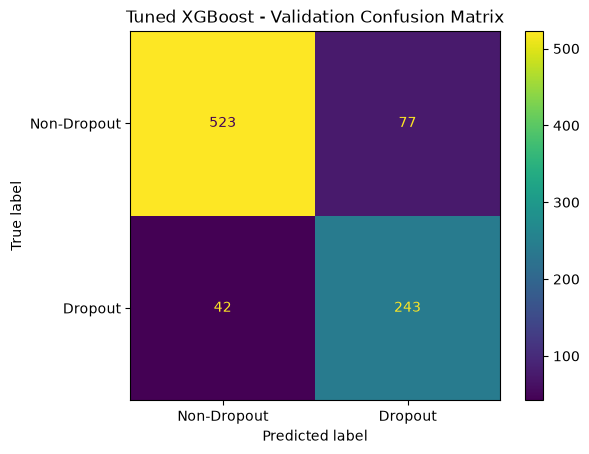


[Tuned XGBoost - Test 최종 성능]
Accuracy       : 0.8780
Precision      : 0.8034
Dropout Recall : 0.8204
F1-score       : 0.8118
ROC-AUC        : 0.9320

[Classification Report]
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.91      0.91       601
     Dropout       0.80      0.82      0.81       284

    accuracy                           0.88       885
   macro avg       0.86      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885


[Test Confusion Matrix]
[[544  57]
 [ 51 233]]

구성:
TN (실제 0 → 예측 0) : 544
FP (실제 0 → 예측 1) : 57
FN (실제 1 → 예측 0) : 51
TP (실제 1 → 예측 1) : 233


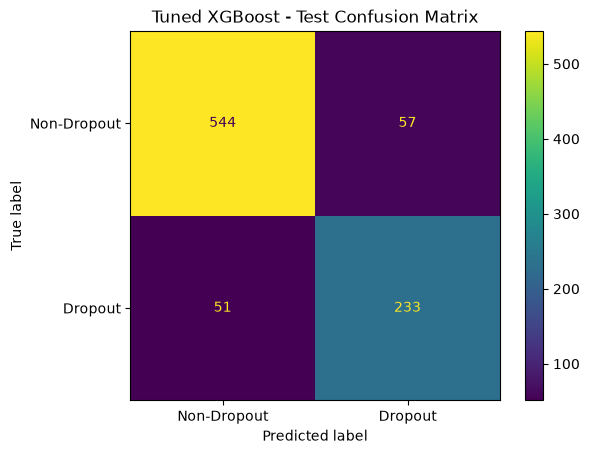


[Tuned XGBoost 최종 결과 요약]
        Model  Accuracy  Precision  Dropout Recall  F1-score  ROC-AUC
Tuned XGBoost  0.877966   0.803448        0.820423  0.811847 0.932021


In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

import matplotlib.pyplot as plt


# =====================================================================
# [1단계] 데이터 불러오기
# =====================================================================
# 전처리가 끝난 Train / Validation / Test 데이터를 불러옵니다.
#
# Train      → RandomizedSearchCV를 통한 모델 학습 및 하이퍼파라미터 탐색
# Validation → 튜닝된 모델의 중간 성능 확인
# Test       → 최종 성능 평가
# =====================================================================

train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')


# =====================================================================
# [2단계] X와 y 분리
# =====================================================================
# X → 모델이 학습할 Feature(설명변수)
# y → 모델이 예측할 Target(정답)
#
# 현재 프로젝트:
# 0 = Non-Dropout
# 1 = Dropout
# =====================================================================

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_val = val_df.drop('target', axis=1)
y_val = val_df['target']

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']


# =====================================================================
# [3단계] 클래스 불균형 가중치 계산
# =====================================================================
# Dropout(1)과 Non-Dropout(0)의 데이터 수가 다르기 때문에
# Dropout 클래스가 학습 과정에서 상대적으로 더 중요하게 반영되도록
# scale_pos_weight를 계산합니다.
#
# 공식:
#
#       Non-Dropout(0) 개수
# ------------------------------
#       Dropout(1) 개수
#
# 예를 들어
# 0이 600명이고 1이 284명이면
#
# 600 / 284 ≈ 2.11
#
# 따라서 Dropout을 틀렸을 때 더 큰 가중치를 주게 됩니다.
# =====================================================================

weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(f"scale_pos_weight = {weight:.4f}")


# =====================================================================
# [4단계] XGBoost 기본 모델 생성
# =====================================================================
# 여기서는 하이퍼파라미터를 하나하나 최적화하지 않고,
# RandomizedSearchCV가 아래 param_dist에 있는 후보들을
# 조합하여 최적의 설정을 찾도록 합니다.
# =====================================================================

xgb_model = XGBClassifier(
    scale_pos_weight=weight,
    random_state=42
)


# =====================================================================
# [5단계] 하이퍼파라미터 후보 설정
# =====================================================================
# 하이퍼파라미터:
#
# n_estimators
# → 생성할 결정트리의 개수
#
# max_depth
# → 각각의 결정트리가 가질 수 있는 최대 깊이
#
# learning_rate
# → 각각의 트리가 기존 모델을 얼마나 보완할지 결정하는 학습률
#
# subsample
# → 각 트리를 학습할 때 사용할 데이터의 비율
#
# RandomizedSearchCV는 아래 후보들 중에서
# 무작위로 조합을 선택하여 성능을 비교합니다.
# =====================================================================

param_dist = {

    'n_estimators': [
        100,
        200,
        300
    ],

    'max_depth': [
        3,
        5,
        7
    ],

    'learning_rate': [
        0.01,
        0.05,
        0.1
    ],

    'subsample': [
        0.8,
        0.9,
        1.0
    ]
}


# =====================================================================
# [6단계] Stratified K-Fold 설정
# =====================================================================
# Train 데이터를 5개의 Fold로 나누어 교차검증합니다.
#
# 일반 K-Fold와 달리 Stratified K-Fold는
# 각 Fold마다 Dropout / Non-Dropout 비율이
# 최대한 비슷하게 유지되도록 데이터를 나눕니다.
#
# n_splits=5
# → 5개의 Fold 사용
#
# shuffle=True
# → 데이터를 섞은 뒤 Fold 생성
#
# random_state=42
# → 매번 동일한 방식으로 나누어지도록 설정
# =====================================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =====================================================================
# [7단계] RandomizedSearchCV 설정
# =====================================================================
# RandomizedSearchCV는
#
# ① 하이퍼파라미터 후보 조합을 무작위로 선택
# ② 각 조합에 대해 5-Fold 교차검증
# ③ 각 조합의 평균 F1-score 계산
# ④ 가장 높은 F1-score를 기록한 조합 선택
#
# scoring='f1'
# → 우리가 정한 튜닝의 최우선 기준인 F1-score를 사용합니다.
#
# n_iter=30
# → 전체 후보 조합 중 30개의 조합을 무작위로 테스트합니다.
# =====================================================================

random_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=param_dist,

    n_iter=30,

    scoring='f1',

    cv=skf,

    random_state=42,

    n_jobs=-1,

    return_train_score=True
)


# =====================================================================
# [8단계] 하이퍼파라미터 튜닝 및 모델 학습
# =====================================================================

print("\nXGBoost 하이퍼파라미터 튜닝 시작...")

random_search.fit(
    X_train,
    y_train
)

print("튜닝 완료!")


# =====================================================================
# [9단계] 최적 하이퍼파라미터 확인
# =====================================================================
# best_params_
# → CV에서 가장 높은 F1-score를 기록한 하이퍼파라미터 조합
#
# best_score_
# → 해당 조합의 평균 CV F1-score
# =====================================================================

print("\n" + "=" * 60)
print("[최적 하이퍼파라미터]")
print("=" * 60)

print(random_search.best_params_)

print(
    f"\n최고 CV 평균 F1-score : "
    f"{random_search.best_score_:.4f}"
)


# =====================================================================
# [10단계] 최적 모델 가져오기
# =====================================================================
# RandomizedSearchCV가 여러 하이퍼파라미터 조합을 비교한 후
# 가장 높은 F1-score를 기록한 모델을 가져옵니다.
#
# ★ 매우 중요 ★
#
# 앞으로 Validation / Test 평가와 Feature Importance 분석에는
# 반드시 이 best_model을 사용합니다.
# =====================================================================

best_model = random_search.best_estimator_


# =====================================================================
# [11단계] Tuned XGBoost Feature Importance
# =====================================================================
# ★ 중요 ★
#
# 여기서는 Baseline 모델이 아니라
# RandomizedSearchCV가 선택한 "최적 Tuned 모델"인
# best_model의 Feature Importance를 사용합니다.
#
# Importance가 높을수록
# XGBoost가 중도탈락 여부를 예측하는 과정에서
# 해당 Feature를 상대적으로 중요하게 활용했다는 의미입니다.
#
# 단,
# Feature Importance가 높다고 해서
# 해당 변수가 중도탈락의 "원인"이라는 뜻은 아닙니다.
# =====================================================================

importance_df = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': best_model.feature_importances_

}).sort_values(

    by='Importance',

    ascending=False
)


print("\n" + "=" * 60)
print("[Tuned XGBoost - Feature Importance TOP 10]")
print("=" * 60)

print(
    importance_df
    .head(10)
    .to_string(index=False)
)


# =====================================================================
# [12단계] RandomizedSearchCV 하이퍼파라미터 탐색 결과 확인
# =====================================================================
# 모든 테스트 조합 중 성능이 좋았던 상위 10개 조합을 확인합니다.
#
# mean_test_score
# → 5-Fold CV의 평균 F1-score
#
# std_test_score
# → Fold마다 F1-score가 얼마나 차이났는지 나타내는 값
#
# rank_test_score
# → 전체 조합 중 성능 순위
# =====================================================================

cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results = cv_results.sort_values(
    by='rank_test_score'
)


print("\n" + "=" * 60)
print("[RandomizedSearchCV 하이퍼파라미터 탐색 결과 TOP 10]")
print("=" * 60)

print(
    cv_results[
        [
            'rank_test_score',
            'mean_test_score',
            'std_test_score',
            'param_n_estimators',
            'param_max_depth',
            'param_learning_rate',
            'param_subsample'
        ]
    ]
    .head(10)
    .to_string(index=False)
)


# =====================================================================
# [13단계] Validation 데이터 예측
# =====================================================================
# 튜닝이 완료된 best_model을 사용하여
# Validation 데이터의 Dropout 확률을 예측합니다.
#
# [:, 1]
# → Dropout(1)일 확률만 가져옵니다.
#
# Threshold 0.5
# → Dropout 확률이 50% 이상이면 1(Dropout)
# → 50% 미만이면 0(Non-Dropout)
# =====================================================================

val_proba = best_model.predict_proba(
    X_val
)[:, 1]

val_pred = (
    val_proba >= 0.5
).astype(int)


# =====================================================================
# [14단계] Validation 성능 계산
# =====================================================================

val_accuracy = accuracy_score(
    y_val,
    val_pred
)

val_precision = precision_score(
    y_val,
    val_pred,
    pos_label=1
)

val_recall = recall_score(
    y_val,
    val_pred,
    pos_label=1
)

val_f1 = f1_score(
    y_val,
    val_pred,
    pos_label=1
)

val_roc_auc = roc_auc_score(
    y_val,
    val_proba
)


# =====================================================================
# [15단계] Validation 결과 출력
# =====================================================================

print("\n" + "=" * 60)
print("[Tuned XGBoost - Validation 성능]")
print("=" * 60)

print(
    f"Accuracy       : {val_accuracy:.4f}"
)

print(
    f"Precision      : {val_precision:.4f}"
)

print(
    f"Dropout Recall : {val_recall:.4f}"
)

print(
    f"F1-score       : {val_f1:.4f}"
)

print(
    f"ROC-AUC        : {val_roc_auc:.4f}"
)


print("\n[Classification Report]")

print(
    classification_report(
        y_val,
        val_pred,
        target_names=[
            'Non-Dropout',
            'Dropout'
        ]
    )
)


# =====================================================================
# [16단계] Validation Confusion Matrix
# =====================================================================

val_cm = confusion_matrix(
    y_val,
    val_pred
)

print("\n[Validation Confusion Matrix]")

print(val_cm)

print("\n구성:")

print(
    f"TN (실제 0 → 예측 0) : "
    f"{val_cm[0, 0]}"
)

print(
    f"FP (실제 0 → 예측 1) : "
    f"{val_cm[0, 1]}"
)

print(
    f"FN (실제 1 → 예측 0) : "
    f"{val_cm[1, 0]}"
)

print(
    f"TP (실제 1 → 예측 1) : "
    f"{val_cm[1, 1]}"
)


# Validation Confusion Matrix 시각화

ConfusionMatrixDisplay(
    confusion_matrix=val_cm,
    display_labels=[
        'Non-Dropout',
        'Dropout'
    ]
).plot()

plt.title(
    'Tuned XGBoost - Validation Confusion Matrix'
)

plt.show()


# =====================================================================
# [17단계] Test 데이터 예측
# =====================================================================
# Test 데이터는 최종 성능 평가에만 사용합니다.
#
# Validation에서 사용한 것과 동일하게
# Threshold 0.5를 사용합니다.
#
# Test 결과는 최종 모델의 일반화 성능을 확인하기 위한 결과입니다.
# =====================================================================

test_proba = best_model.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_proba >= 0.5
).astype(int)


# =====================================================================
# [18단계] Test 성능 계산
# =====================================================================

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred,
    pos_label=1
)

test_recall = recall_score(
    y_test,
    test_pred,
    pos_label=1
)

test_f1 = f1_score(
    y_test,
    test_pred,
    pos_label=1
)

test_roc_auc = roc_auc_score(
    y_test,
    test_proba
)


# =====================================================================
# [19단계] Tuned XGBoost 최종 Test 결과
# =====================================================================

print("\n" + "=" * 60)
print("[Tuned XGBoost - Test 최종 성능]")
print("=" * 60)

print(
    f"Accuracy       : {test_accuracy:.4f}"
)

print(
    f"Precision      : {test_precision:.4f}"
)

print(
    f"Dropout Recall : {test_recall:.4f}"
)

print(
    f"F1-score       : {test_f1:.4f}"
)

print(
    f"ROC-AUC        : {test_roc_auc:.4f}"
)


print("\n[Classification Report]")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            'Non-Dropout',
            'Dropout'
        ]
    )
)


# =====================================================================
# [20단계] Test Confusion Matrix
# =====================================================================

test_cm = confusion_matrix(
    y_test,
    test_pred
)

print("\n[Test Confusion Matrix]")

print(test_cm)

print("\n구성:")

print(
    f"TN (실제 0 → 예측 0) : "
    f"{test_cm[0, 0]}"
)

print(
    f"FP (실제 0 → 예측 1) : "
    f"{test_cm[0, 1]}"
)

print(
    f"FN (실제 1 → 예측 0) : "
    f"{test_cm[1, 0]}"
)

print(
    f"TP (실제 1 → 예측 1) : "
    f"{test_cm[1, 1]}"
)


# Test Confusion Matrix 시각화

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=[
        'Non-Dropout',
        'Dropout'
    ]
).plot()

plt.title(
    'Tuned XGBoost - Test Confusion Matrix'
)

plt.show()


# =====================================================================
# [21단계] Tuned XGBoost 최종 결과 요약
# =====================================================================
# Baseline XGBoost와 비교하기 위한 최종 결과표입니다.
# =====================================================================

tuned_result = pd.DataFrame({

    'Model': [
        'Tuned XGBoost'
    ],

    'Accuracy': [
        test_accuracy
    ],

    'Precision': [
        test_precision
    ],

    'Dropout Recall': [
        test_recall
    ],

    'F1-score': [
        test_f1
    ],

    'ROC-AUC': [
        test_roc_auc
    ]
})


print("\n" + "=" * 60)
print("[Tuned XGBoost 최종 결과 요약]")
print("=" * 60)

print(
    tuned_result.to_string(
        index=False
    )
)

하이퍼파라미터	최적값	의미
n_estimators	300	결정트리를 300개 사용
max_depth	5	각 트리의 최대 깊이를 5로 제한
learning_rate	0.01	한 번에 조금씩 학습
subsample	0.9	각 트리를 학습할 때 데이터의 90% 사용

하이퍼파라미터	  최적값	  의미  
n_estimators	300	       결정트리를 300개 사용
max_depth     	5	       각 트리의 최대 깊이를 5로 제한
learning_rate	0.01	   한 번에 조금씩 학습
subsample	    0.9	       각 트리를 학습할 때 데이터의 90% 사용

# 프리시젼 트레이드오프

Baseline:  
Precision = 0.8159  
  
Tuned:  
Precision = 0.8034  

=> 모델이 Dropout을 더 많이 찾아내도록 움직였기 때문  
  
Baseline  
TP = 226  
FP = 51  
  
Tuned  
TP = 233  
FP = 57  

# Feature Importance  
  
1순위 : sem2_approval_rate        0.226252  
2순위 : financial_risk_score      0.040785  

# "2학기 승인율이 중도탈락 여부를 예측하는 데 가장 중요한 변수로 나타났다."

# 가설: 학생의 학업 수행 및 재정 관련 요인이 중도탈락 여부를 예측하는 데 중요한 영향을 미칠 것이다.

학업 관련 변수
sem2_approval_rate → Importance 0.226
sem1_approval_rate → 0.024
Curricular units 1st sem (enrolled) → 0.027 

재정 관련 변수
financial_risk_score → 0.041
Tuition fees up to date → 0.035

XGBoost 모델의 하이퍼파라미터를 F1-score 기준으로 튜닝한 결과,   
Test F1-score가 0.8057에서 0.8118로 향상되었으며,  
특히 중도탈락 학생에 대한 Recall이 79.6%에서 82.0%로 개선되었다.  
또한 ROC-AUC가 0.9149에서 0.9320으로 상승하여 전반적인 중도탈락 학생의 변별력도 개선되었다.  
Feature Importance 분석에서는 2학기 승인율이 가장 중요한 변수로 나타났으며,  
학업 수행 및 재정 관련 변수가 중도탈락 예측에 중요한 역할을 하는 것으로 확인되어 설정한 가설을 뒷받침하는 결과를 얻었다.

# reports/model_results.csv

In [2]:
# =====================================================================
# [최종 모델 비교 결과 저장]
# =====================================================================

model_results = pd.DataFrame({
    'Model': [
        'Baseline XGBoost',
        'Tuned XGBoost'
    ],

    'Accuracy': [
        0.876836,
        0.877966
    ],

    'Precision': [
        0.815884,
        0.803448
    ],

    'Dropout Recall': [
        0.795775,
        0.820423
    ],

    'F1-score': [
        0.805704,
        0.811847
    ],

    'ROC-AUC': [
        0.914942,
        0.932021
    ]
})

model_results.to_csv(
    '../reports/model_results.csv',
    index=False
)

print("\nmodel_results.csv 저장 완료!")


model_results.csv 저장 완료!


# 산출물 도출

In [3]:
import joblib

# =====================================================================
# [최종 모델 저장]
# =====================================================================
# 하이퍼파라미터 튜닝이 완료된 최종 XGBoost 모델을
# joblib 파일로 저장합니다.
#
# 이후 새로운 학생 데이터가 들어왔을 때
# 다시 학습하지 않고 이 모델을 불러와 예측할 수 있습니다.
# =====================================================================

joblib.dump(
    best_model,
    '../models/xgboost.joblib'
)

print("\nxgboost.joblib 저장 완료!")


xgboost.joblib 저장 완료!


테스트 예측은 안하고
임계값이랑 이터레이션 수정

